# Projet 12 - ZenAssist : Étape 1 - Analyse Exploratoire des Données (EDA)

Ce notebook présente l'analyse exploratoire complète du dataset de réclamations clients de ZenAssist (`dataset.csv`).

### Objectifs :
1. **Charger et explorer la structure des données**.
2. **Filtrer et nettoyer les données** (gestion des valeurs nulles, doublons et masques CFPB).
3. **Harmoniser la taxonomie des catégories (`Tag`)**.
4. **Visualiser la distribution des catégories et la longueur des réclamations**.
5. **Créer les jeux d'entraînement, de test et le sous-échantillon pour LLM (~1 000 exemples)**.
6. **Formaliser la métrique de latence (temps de réponse)**.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Configuration style graphique
plt.style.use('ggplot')
sns.set_palette('viridis')
%matplotlib inline

## 1. Chargement et inspection initiale

In [2]:
csv_path = 'dataset/dataset.csv'
usecols = ['Consumer Claim', 'Tag', 'Date received', 'Company']

print('Chargement du dataset...')
df = pd.read_csv(csv_path, usecols=usecols, low_memory=False)
print(f'Nombre total de lignes : {len(df):,}')
df.head()

Chargement du dataset...
Nombre total de lignes : 1,282,355


,Date received,Tag,Consumer Claim,Company
0,05/10/2019,Checking or savings account,NaN,NAVY FEDERAL CREDIT UNION
1,05/10/2019,Checking or savings account,NaN,BOEING EMPLOYEES CREDIT UNION
2,05/10/2019,Debt collection,NaN,CURO Intermediate Holdings
3,05/10/2019,"Credit reporting, credit repair services, or o...",NaN,Ad Astra Recovery Services Inc
4,05/10/2019,Checking or savings account,NaN,ALLY FINANCIAL INC.


## 2. Nettoyage et Filtrage des Réclamations

In [3]:
# Filtrer les lignes sans texte de réclamation
df_clean = df.dropna(subset=['Consumer Claim']).copy()
df_clean['Consumer Claim'] = df_clean['Consumer Claim'].astype(str).str.strip()
df_clean = df_clean[df_clean['Consumer Claim'] != '']
print(f'Lignes avec texte réclamations : {len(df_clean):,} ({len(df_clean)/len(df)*100:.2f}%)')

Lignes avec texte réclamations : 383,564 (29.91%)


In [4]:
# Suppression des doublons exacts
df_clean = df_clean.drop_duplicates(subset=['Consumer Claim', 'Tag'])
print(f'Nombre de réclamations uniques : {len(df_clean):,}')

Nombre de réclamations uniques : 367,123


## 3. Harmonisation de la taxonomie des catégories (`Tag`)

In [5]:
tag_mapping = {
    'Credit reporting, credit repair services, or other personal consumer reports': 'Credit reporting',
    'Credit reporting': 'Credit reporting',
    'Credit card or prepaid card': 'Credit card / Prepaid card',
    'Credit card': 'Credit card / Prepaid card',
    'Prepaid card': 'Credit card / Prepaid card',
    'Bank account or service': 'Bank account / Savings',
    'Checking or savings account': 'Bank account / Savings',
    'Payday loan, title loan, or personal loan': 'Payday & Personal loan',
    'Payday loan': 'Payday & Personal loan',
    'Consumer Loan': 'Payday & Personal loan',
    'Money transfer, virtual currency, or money service': 'Money transfer / Crypto',
    'Money transfers': 'Money transfer / Crypto',
    'Virtual currency': 'Money transfer / Crypto',
    'Mortgage': 'Mortgage',
    'Student loan': 'Student loan',
    'Vehicle loan or lease': 'Vehicle loan / Lease',
    'Debt collection': 'Debt collection',
    'Other financial service': 'Other financial service'
}

df_clean['Tag_Clean'] = df_clean['Tag'].map(tag_mapping).fillna(df_clean['Tag'])
clean_tag_counts = df_clean['Tag_Clean'].value_counts()
print(clean_tag_counts)

Tag_Clean
Credit reporting              110293
Debt collection                84317
Mortgage                       52945
Credit card / Prepaid card     41497
Bank account / Savings         27714
Student loan                   21781
Payday & Personal loan         15598
Money transfer / Crypto         6967
Vehicle loan / Lease            5720
Other financial service          291
Name: count, dtype: int64


## 4. Visualisations de l'Analyse Exploratoire

/tmp/ipykernel_9063/1204978342.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=clean_tag_counts.values, y=clean_tag_counts.index, ax=axes[0], palette='viridis')


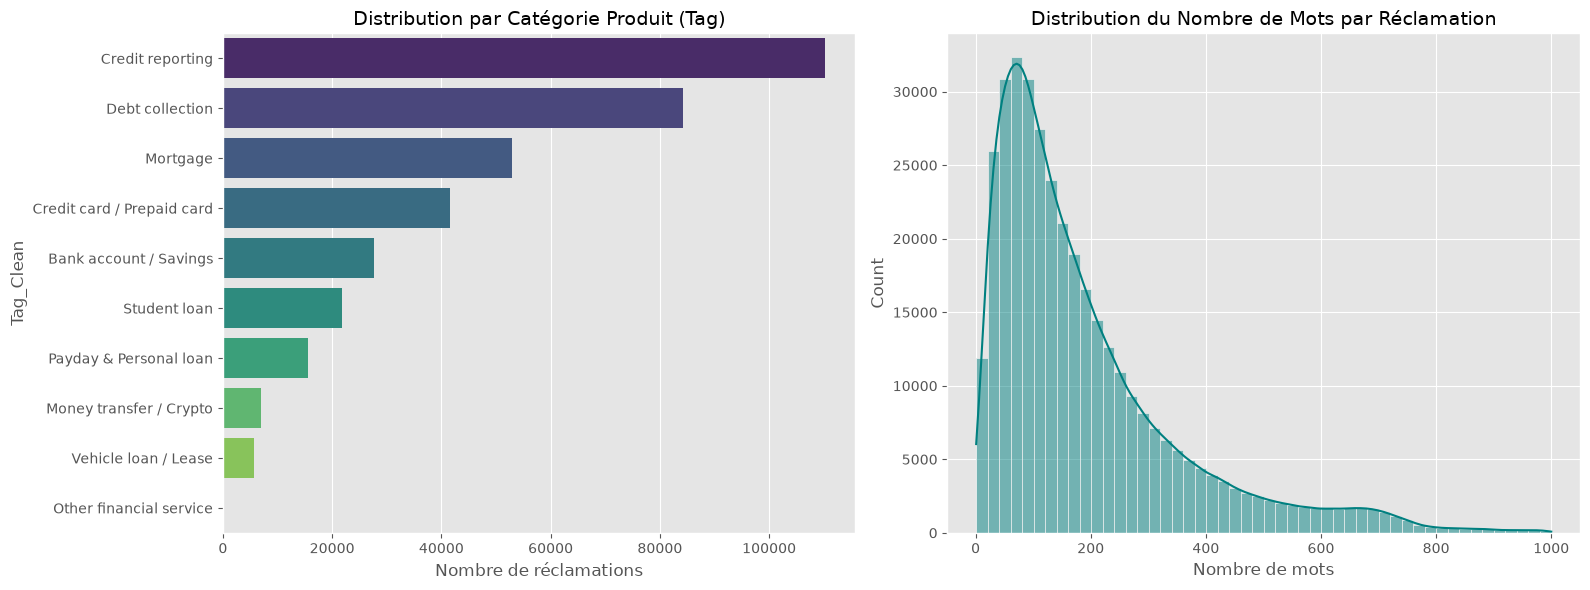

In [6]:
df_clean['word_count'] = df_clean['Consumer Claim'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=clean_tag_counts.values, y=clean_tag_counts.index, ax=axes[0], palette='viridis')
axes[0].set_title('Distribution par Catégorie Produit (Tag)', fontsize=14)
axes[0].set_xlabel('Nombre de réclamations')

sns.histplot(df_clean[df_clean['word_count'] <= 1000]['word_count'], bins=50, kde=True, ax=axes[1], color='teal')
axes[1].set_title('Distribution du Nombre de Mots par Réclamation', fontsize=14)
axes[1].set_xlabel('Nombre de mots')

plt.tight_layout()
plt.show()

## 5. Découpage des jeux de données (Train, Test & LLM Sample)

In [7]:
valid_tags = clean_tag_counts[clean_tag_counts >= 50].index
df_filtered = df_clean[df_clean['Tag_Clean'].isin(valid_tags)].copy()

train_df, test_df = train_test_split(df_filtered, test_size=0.20, random_state=42, stratify=df_filtered['Tag_Clean'])
llm_sample_df, _ = train_test_split(test_df, train_size=1000, random_state=42, stratify=test_df['Tag_Clean'])

print(f'Train set : {len(train_df):,} exemples')
print(f'Test set complet : {len(test_df):,} exemples')
print(f'LLM Test Sample : {len(llm_sample_df):,} exemples')

train_df[['Consumer Claim', 'Tag_Clean']].to_csv('dataset/processed_train.csv', index=False)
test_df[['Consumer Claim', 'Tag_Clean']].to_csv('dataset/processed_test.csv', index=False)
llm_sample_df[['Consumer Claim', 'Tag_Clean']].to_csv('dataset/llm_test_sample.csv', index=False)
print('Fichiers CSV sauvegardés avec succès !')

Train set : 293,698 exemples
Test set complet : 73,425 exemples
LLM Test Sample : 1,000 exemples
Fichiers CSV sauvegardés avec succès !
